# Побудова конвеєра даних за допомогою dlt

У цьому блокноті ми створимо повний конвеєр даних з нуля, використовуючи **dlt**.

Наша мета проста:

→ Отримати реальні дані з API  
→ Перетворити їх на чисті реляційні таблиці  
→ Завантажити їх у базу даних  
→ Дослідити та проаналізувати їх  

Ми використаємо **custom API** як джерело даних і **DuckDB** як нашу базу даних.

Протягом процесу ви дізнаєтесь:

- Що таке джерело (source) dlt  
- Що робить конвеєр (pipeline) dlt  
- Як дані проходять етапи Extract → Normalize → Load  
- Як інспектувати та досліджувати фінальний набір даних  

До кінця ви зрозумієте не лише те, як запустити конвеєр, а й те, що відбувається на кожному етапі.

## 📦 Крок 0: Встановлення залежностей

In [1]:
# спочатку встановимо залежності
!pip -q install dlt[duckdb]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.9/348.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 626.2 kB/s eta 0:00:00


In [2]:
!dlt --version

dlt 1.22.2


## 📚 Крок 1: Імпорт бібліотек

In [3]:
"""dlt pipeline to ingest NYC taxi data from the Zoomcamp REST API."""

from typing import Any, Iterator

import dlt
from dlt.sources.helpers.rest_client import RESTClient
from dlt.sources.helpers.rest_client.paginators import PageNumberPaginator

## 🔗 Крок 2: Визначення джерела API (NYC Yellow Taxi trip data from a custom API)

In [4]:
BASE_URL = "https://us-central1-dlthub-analytics.cloudfunctions.net"
ENDPOINT = "data_engineering_zoomcamp_api"

In [5]:
@dlt.resource(name="nyc_taxi_trips")
def nyc_taxi_trips() -> Iterator[Any]:
    """Yield pages of NYC taxi trips from the Zoomcamp demo API."""
    client = RESTClient(
        base_url=BASE_URL,
        paginator=PageNumberPaginator(
            base_page=1,
            total_path=None,
        ),
    )

    # Pagination: API returns 1,000 records per page and stops with an empty page.
    for page in client.paginate(ENDPOINT):
        yield page

## 🔧 Крок 3: Створення конвеєра dlt

In [6]:
taxi_pipeline = dlt.pipeline(
    pipeline_name="taxi_pipeline",
    destination="duckdb",
    dataset_name="nyc_taxi_data",
    progress="log" # logs the pipeline run (Optiona)
)

## ⬇️ Крок 4: Extract (Витяг)

Тепер ми запускаємо перший етап: **Extract**. На цьому етапі дані завантажуються з API у локальну робочу папку, але ще не в базу даних.

In [7]:
extract_info = taxi_pipeline.extract(nyc_taxi_trips())
print(extract_info)  # noqa: T20

--------------------------------- Extract taxi ---------------------------------
Resources: 0/1 (0.0%) | Time: 0.00s | Rate: 0.00/s
Memory usage: 228.60 MB (11.30%) | CPU usage: 0.00%

--------------------------------- Extract taxi ---------------------------------
Resources: 0/1 (0.0%) | Time: 2.59s | Rate: 0.00/s
nyc_taxi_trips: 1000  | Time: 0.00s | Rate: 72315586.21/s
Memory usage: 231.46 MB (11.40%) | CPU usage: 0.00%

--------------------------------- Extract taxi ---------------------------------
Resources: 0/1 (0.0%) | Time: 5.16s | Rate: 0.00/s
nyc_taxi_trips: 2000  | Time: 2.57s | Rate: 777.45/s
Memory usage: 233.06 MB (11.40%) | CPU usage: 0.00%

--------------------------------- Extract taxi ---------------------------------
Resources: 0/1 (0.0%) | Time: 7.58s | Rate: 0.00/s
nyc_taxi_trips: 3000  | Time: 5.00s | Rate: 600.38/s
Memory usage: 234.60 MB (11.40%) | CPU usage: 0.00%

--------------------------------- Extract taxi ---------------------------------
Resources: 0/1 

In [8]:
print(extract_info)


Load package 1772525224.5872824 is EXTRACTED and NOT YET LOADED to the destination and contains no failed jobs


In [25]:
from datetime import datetime

load_id = extract_info.loads_ids[-1]
m = extract_info.metrics[load_id][0]

def format_ts(ts):
    """Переводим UNIX timestamp в читаемую дату"""
    return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d %H:%M:%S")

print("=== DAG ===")
for src, dst in m['dag']:
    print(f"{src} → {dst}")

print("\n=== Общая информация ===")
print(f"Схема: {m['schema_name']}")
print(f"Начало: {m['started_at'].strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Окончание: {m['finished_at'].strftime('%Y-%m-%d %H:%M:%S')}")

print("Resources:", list(m["resource_metrics"].keys()))
print("Tables:", list(m["table_metrics"].keys()))
print("Load ID:", load_id)
print()

for resource, rm in m["resource_metrics"].items():
    print(f"Resource: {resource}")
    print(f"rows extracted: {rm.items_count}")
    print()



=== DAG ===
nyc_taxi_trips → nyc_taxi_trips

=== Общая информация ===
Схема: taxi
Начало: 2026-03-03 08:07:04
Окончание: 2026-03-03 08:07:32
Resources: ['nyc_taxi_trips']
Tables: ['nyc_taxi_trips']
Load ID: 1772525224.5872824

Resource: nyc_taxi_trips
rows extracted: 10000



## 🔄 Step 5: Normalize

Now we run **Normalize**. This is where dlt transforms raw JSON into a clean relational structure.

During normalization, dlt does three key things:

### 1. Adds Tracking Columns to the Main Table

dlt adds special columns to every table:
- `_dlt_id`: A unique identifier for each row
- `_dlt_load_id`: Links each row to the load job that created it

### 2. Flattens Nested Data into Child Tables

APIs often return nested JSON. For example, a book can have multiple authors (a list), multiple editions, and multiple identifiers.

dlt flattens these nested structures into separate **child tables** with names like:
- `books__author_name`
- `books__author_key`
- `books__language`

Each child table has a `_dlt_parent_id` column that references `_dlt_id` in the parent table. This is how dlt maintains relationships.

### 3. Creates Metadata Tables

dlt also creates internal tables to track pipeline state:
- `_dlt_loads`: Tracks load history (when data was loaded, status)
- `_dlt_pipeline_state`: Stores pipeline state for incremental loading
- `_dlt_version`: Tracks schema versions

In the next cell, we will print a summary showing which tables were created.

In [23]:
normalize_info = taxi_pipeline.normalize()

--------------------- Normalize taxi in 1772525224.5872824 ---------------------
Files: 0/2 (0.0%) | Time: 0.00s | Rate: 0.00/s
Memory usage: 252.51 MB (12.00%) | CPU usage: 0.00%

--------------------- Normalize taxi in 1772525224.5872824 ---------------------
Files: 0/2 (0.0%) | Time: 0.00s | Rate: 0.00/s
Items: 0  | Time: 0.00s | Rate: 0.00/s
Memory usage: 252.51 MB (12.00%) | CPU usage: 0.00%



2026-03-03 08:36:47,372|[WARNING]|482|135135034392576|dlt|validate.py|verify_normalized_table:91|In schema `taxi`: The following columns in table 'nyc_taxi_trips' did not receive any data during this load and therefore could not have their types inferred:
  - rate_code
  - mta_tax

Unless type hints are provided, these columns will not be materialized in the destination.
One way to provide type hints is to use the 'columns' argument in the '@dlt.resource' decorator.  For example:

@dlt.resource(columns={'rate_code': {'data_type': 'text'}})



--------------------- Normalize taxi in 1772525224.5872824 ---------------------
Files: 2/2 (100.0%) | Time: 2.55s | Rate: 0.79/s
Items: 0  | Time: 2.54s | Rate: 0.00/s
Memory usage: 265.74 MB (12.20%) | CPU usage: 0.00%

--------------------- Normalize taxi in 1772525224.5872824 ---------------------
Files: 2/2 (100.0%) | Time: 2.55s | Rate: 0.78/s
Items: 10001  | Time: 2.55s | Rate: 3922.94/s
Memory usage: 265.74 MB (12.20%) | CPU usage: 0.00%



In [24]:
load_id = normalize_info.loads_ids[-1]
m = normalize_info.metrics[load_id][0]

print("Load ID:", load_id)
print()

print("Tables created/updated:")
for table_name, tm in m["table_metrics"].items():
    # skip dlt internal tables to keep it beginner-friendly
    if table_name.startswith("_dlt"):
        continue
    print(f"  - {table_name}: {tm.items_count} rows")


Load ID: 1772525224.5872824

Tables created/updated:
  - nyc_taxi_trips: 10000 rows


## 📤 Крок 6: Load (Завантаження)

Фінальний етап, де дані записуються в DuckDB.

In [26]:
load_info = taxi_pipeline.load()
print(load_info)

----------------------- Load taxi in 1772525224.5872824 ------------------------
Jobs: 0/2 (0.0%) | Time: 0.00s | Rate: 0.00/s
Memory usage: 265.74 MB (11.30%) | CPU usage: 0.00%

----------------------- Load taxi in 1772525224.5872824 ------------------------
Jobs: 1/2 (50.0%) | Time: 3.60s | Rate: 0.28/s
Memory usage: 388.87 MB (12.30%) | CPU usage: 0.00%

----------------------- Load taxi in 1772525224.5872824 ------------------------
Jobs: 2/2 (100.0%) | Time: 3.70s | Rate: 0.54/s
Memory usage: 280.18 MB (11.40%) | CPU usage: 0.00%

Pipeline taxi_pipeline load step completed in 3.70 seconds
1 load package(s) were loaded to destination duckdb and into dataset nyc_taxi_data
The duckdb destination used duckdb:////content/taxi_pipeline.duckdb location to store data
Load package 1772525224.5872824 is LOADED and contains no failed jobs


## 🔎 Крок 7: Перевірка завантажених даних

In [ ]:
!dlt pipeline taxi_pipeline show

^C


In [27]:
# Display schema
taxi_pipeline.default_schema

<dlt.Schema(name='taxi', version=2, tables=['_dlt_version', '_dlt_loads', 'nyc_taxi_trips', '_dlt_pipeline_state'], version_hash='t4Bb9kvrIx0oTHRyi4Clsj68HqFIn/eICvF7QOvhgSc=')>

In [35]:
ds = taxi_pipeline.dataset()  # по умолчанию текущий dataset_name

# посмотреть какие таблицы есть
ds.tables

['nyc_taxi_trips', '_dlt_version', '_dlt_loads', '_dlt_pipeline_state']

In [36]:
# забрать данные в pandas
df = ds.nyc_taxi_trips.df()      # main table
df.head(3)

,end_lat,end_lon,fare_amt,passenger_count,payment_type,start_lat,start_lon,tip_amt,tolls_amt,total_amt,trip_distance,trip_dropoff_date_time,trip_pickup_date_time,surcharge,vendor_name,_dlt_load_id,_dlt_id,store_and_forward
0,40.742963,-73.980072,45.0,1,Credit,40.641525,-73.787442,9.0,4.15,58.15,17.52,2009-06-14 23:48:00+00:00,2009-06-14 23:23:00+00:00,0.0,VTS,1772525224.5872824,qZs50sVmPgJ6Gw,NaN
1,40.740187,-74.005698,6.5,1,Credit,40.722065,-74.009767,1.0,0.00,8.50,1.56,2009-06-18 17:43:00+00:00,2009-06-18 17:35:00+00:00,1.0,VTS,1772525224.5872824,9t0YhZJuu5Niyg,NaN
2,40.718043,-74.004745,12.5,5,Credit,40.761945,-73.983038,2.0,0.00,15.50,3.37,2009-06-10 18:27:00+00:00,2009-06-10 18:08:00+00:00,1.0,VTS,1772525224.5872824,xWYuoga36Dq7Yw,NaN


In [42]:
df.columns

Index(['end_lat', 'end_lon', 'fare_amt', 'passenger_count', 'payment_type',
       'start_lat', 'start_lon', 'tip_amt', 'tolls_amt', 'total_amt',
       'trip_distance', 'trip_dropoff_date_time', 'trip_pickup_date_time',
       'surcharge', 'vendor_name', '_dlt_load_id', '_dlt_id',
       'store_and_forward', 'dropoff_date', 'pickup_date'],
      dtype='object')

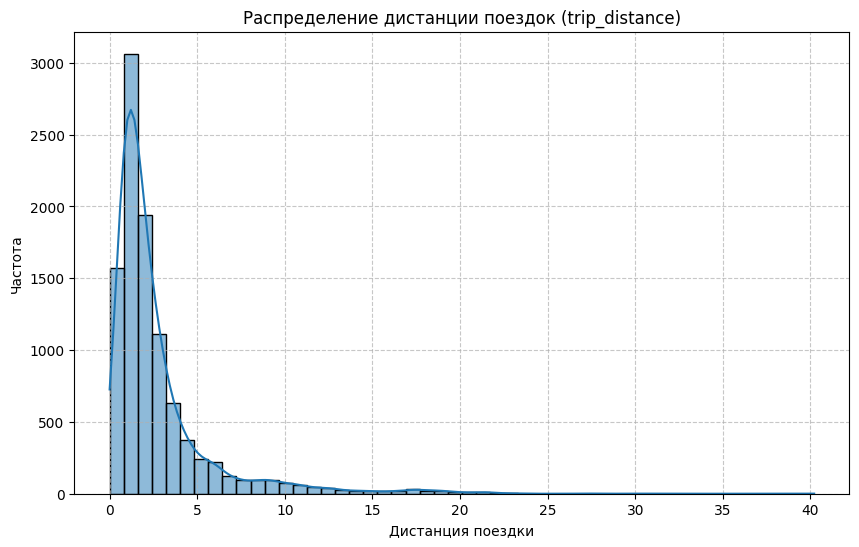

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['trip_distance'], bins=50, kde=True)
plt.title('Распределение дистанции поездок (trip_distance)')
plt.xlabel('Дистанция поездки')
plt.ylabel('Частота')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Question 1: What is the start date and end date of the dataset?

In [ ]:
import pandas as pd

In [ ]:
df['dropoff_date'] = pd.to_datetime(df['trip_dropoff_date_time']).dt.date
df['pickup_date'] = pd.to_datetime(df['trip_pickup_date_time']).dt.date

df.head()

In [44]:
min_dropoff_date = df['dropoff_date'].min()
max_pickup_date = df['pickup_date'].max()

print(f"Минимальная дата высадки: {min_dropoff_date}")
print(f"Максимальная дата посадки: {max_pickup_date}")

Минимальная дата высадки: 2009-06-01
Максимальная дата посадки: 2009-06-30


### Question 2: What proportion of trips are paid with credit card?

In [45]:
credit_card_trips = df[df['payment_type'] == 'Credit'].shape[0]
total_trips = df.shape[0]

proportion_credit_card = credit_card_trips / total_trips

print(f"Доля поездок, оплаченных кредитной картой: {proportion_credit_card:.2%}")

Доля поездок, оплаченных кредитной картой: 26.66%


### Question 3: What is the total amount of money generated in tips?

In [46]:
total_tips_amount = df['tip_amt'].sum()
print(f"Общая сумма денег, полученных в виде чаевых: {total_tips_amount:.2f}")

Общая сумма денег, полученных в виде чаевых: 6063.41


## 💡 Висновок

### Що dlt зробив за нас:
✔ Отримання даних з API  
✔ Нормалізація JSON  
✔ Створення таблиць  
✔ Завантаження в базу даних  
✔ Проста інспекція набору даних  

### Але залишаються певні труднощі:
• Правильне налаштування конфігурації REST API  
• Запам'ятовування синтаксису пагінації  
• Написання Python або SQL для отримання інсайтів  

---

## 🚀 Далі: Робочі процеси на базі LLM

dlt інтегрує LLM безпосередньо в процес, щоб зробити аналіз даних природнішим. Замість написання коду, ви зможете використовувати природну мову.